# 全球 ERA5 的 IPCC AR6 分區

依 Iturbide et al. (2020) 第 3 節、Figure 1(b) 的官方 **AR6 WGI v4** 邊界建立分區。這是固定的氣候參考區域，不是 NN 或聚類模型，也不保證區內定常。

本 notebook 只需要全球 0.25° 座標與已下載的 ERA5 陸海遮罩，**不讀取溫度、不重訓 NN、不執行 Spatial CV**。原始 ERA5 資料不會被更動。

[論文](https://doi.org/10.5194/essd-12-2959-2020) · [官方邊界](https://github.com/SantanderMetGroup/ATLAS/tree/devel/reference-regions)


In [1]:
from pathlib import Path
import sys
import json
import pandas as pd
import xarray as xr
from IPython.display import display, Image

CURRENT = Path.cwd().resolve()
ROOT = next((p for p in (CURRENT, *CURRENT.parents) if (p / 'src' / 'global_climate_regions.py').is_file()), None)
if ROOT is None:
    raise FileNotFoundError('請從專案內開啟，例如 global/preparation。')
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))
from global_climate_regions import (
    DEFAULT_LSM, DEFAULT_BOUNDARIES, prepare, attach_region_labels,
    geodesic_distance_km,
)

OUTPUT = ROOT / 'data' / 'processed' / 'global_regions' / 'ar6_025'
LSM_PATH = DEFAULT_LSM
LAND_THRESHOLD = 0.5
print('陸海遮罩：', LSM_PATH)
print('輸出目錄：', OUTPUT)


陸海遮罩： D:\論文資料\ERA5\1975-2025_global_hourly\static\era5_land_sea_mask_global_025.nc
輸出目錄： C:\Users\User.DESKTOP-4RV84M1\Desktop\論文\fast parameter estimate\fast_parameter_using_NN\data\processed\global_regions\ar6_025


## 1. 建立或驗證分區

先依格點中心的經緯度分區，再保留 `LSM > 0.5` 的陸地 GRID。首次只下載約 0.7 MB 的邊界；來源版本與檔案雜湊固定。完成的輸出通過驗證後直接重用。更改門檻或 LSM 時請指定另一個輸出目錄。

46 個陸地參考區域不是完整的全球海岸線。位於其外的陸地（例如部分島嶼）另列例外清單，不猜測歸屬。CAR、MED、SEA 同時支援陸地與海洋，仍要靠 LSM 區分。


In [2]:
manifest = prepare(OUTPUT, DEFAULT_BOUNDARIES, LSM_PATH, LAND_THRESHOLD)
summary_keys = [
    'grid_count', 'land_region_count', 'lsm_land_grid_count',
    'analysis_land_grid_count', 'spatial_cv_eligible_count',
    'land_without_land_region_count', 'unassigned_polygon_grid_count',
    'boundary_tie_grid_count',
]
display(pd.DataFrame({'項目': summary_keys, '數量': [manifest[k] for k in summary_keys]}))


Verified existing region lookup: C:\Users\User.DESKTOP-4RV84M1\Desktop\論文\fast parameter estimate\fast_parameter_using_NN\data\processed\global_regions\ar6_025


,項目,數量
0,grid_count,1038240
1,land_region_count,46
2,lsm_land_grid_count,351848
3,analysis_land_grid_count,351004
4,spatial_cv_eligible_count,349565
5,land_without_land_region_count,844
6,unassigned_polygon_grid_count,18
7,boundary_tie_grid_count,11111


## 2. 地圖與各區格點數

顏色只表示區域，不是溫度或氣候趨勢。灰色點是陸地分區之外的 LSM 陸地。格點數不是面積比例：高緯度的 0.25° 格點實際面積較小。


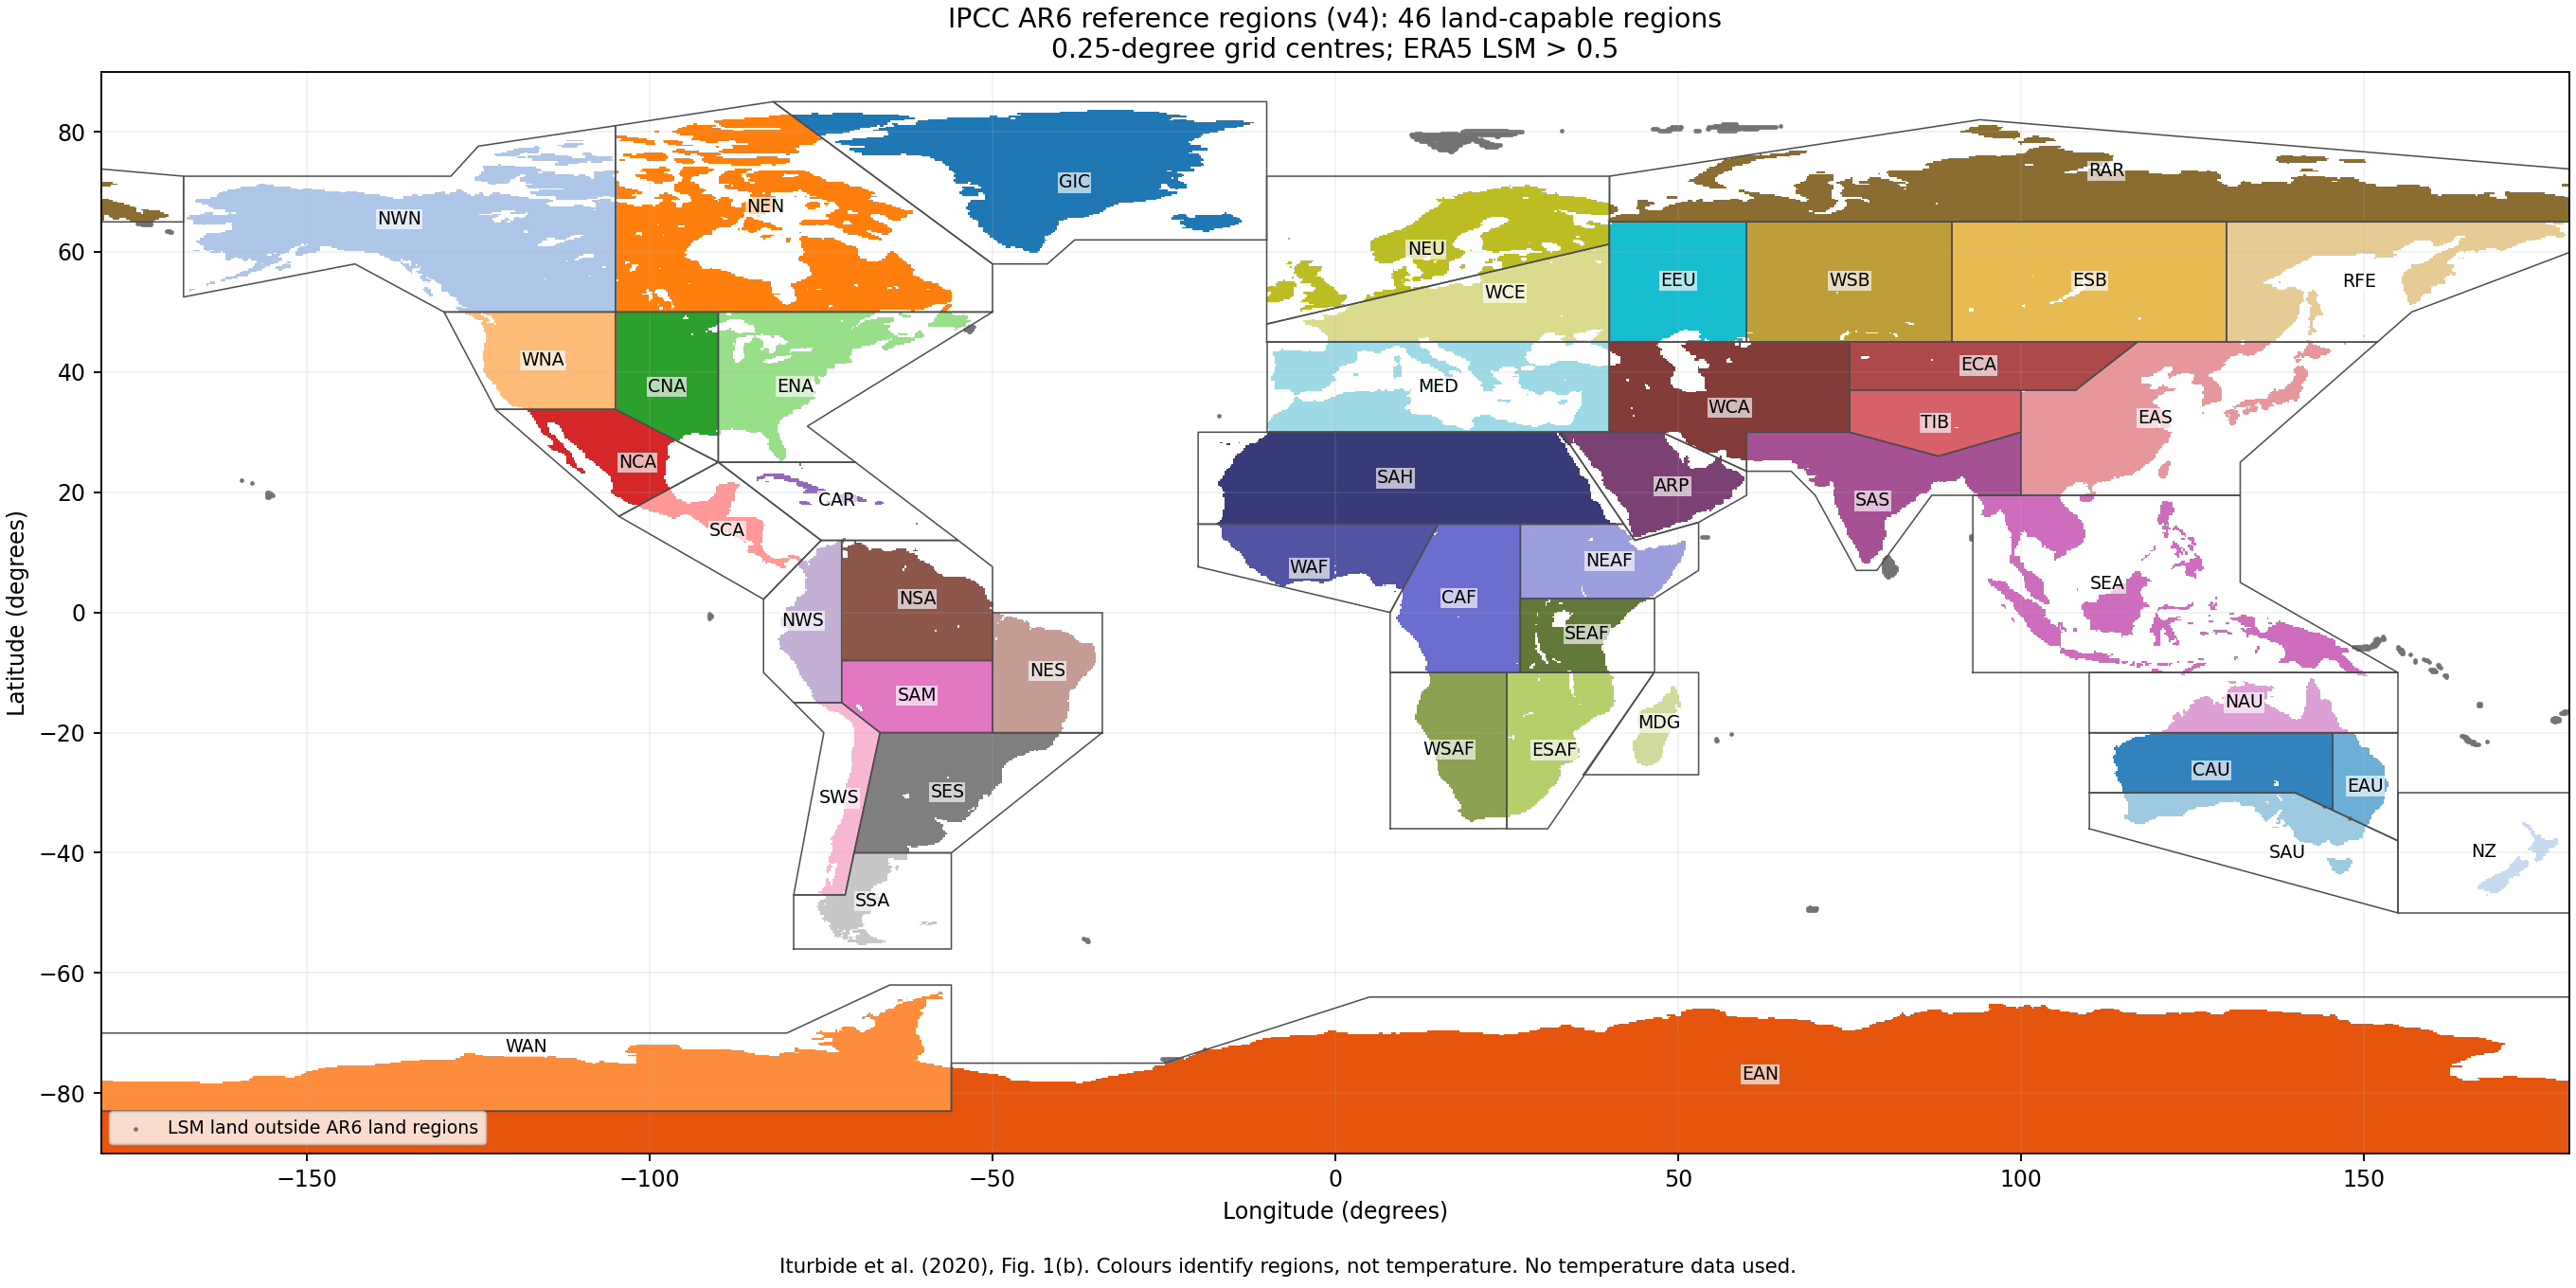

,ar6_region,ar6_region_name,analysis_land_grid_count,spatial_cv_eligible_count
0,GIC,Greenland/Iceland,11858,11858
1,NWN,N.W.North-America,15165,15165
2,NEN,N.E.North-America,12930,12930
3,WNA,W.North-America,4735,4735
4,CNA,C.North-America,4631,4631
5,ENA,E.North-America,5312,5312
6,NCA,N.Central-America,2938,2938
7,SCA,S.Central-America,1309,1309
8,CAR,Caribbean,286,286
9,NWS,N.W.South-America,2754,2754


待決定納入規則的區域外陸地 GRID：844


,latitude,longitude,grid_id_025,ar6_region_id,boundary_matches,lsm,land_mask,analysis_land_mask,spatial_cv_eligible,ar6_region,ar6_region_name,ar6_region_type,exclusion_reason
0,81.25,56.50,50626,46,1,0.567612,1,0,0,ARO,Arctic-Ocean,Ocean,inside_ocean_only_region
1,81.25,56.75,50627,46,1,0.614917,1,0,0,ARO,Arctic-Ocean,Ocean,inside_ocean_only_region
2,81.25,57.00,50628,46,1,0.611265,1,0,0,ARO,Arctic-Ocean,Ocean,inside_ocean_only_region
3,81.25,57.25,50629,46,1,0.607553,1,0,0,ARO,Arctic-Ocean,Ocean,inside_ocean_only_region
4,81.25,57.50,50630,46,1,0.603780,1,0,0,ARO,Arctic-Ocean,Ocean,inside_ocean_only_region
5,81.25,57.75,50631,46,1,0.591914,1,0,0,ARO,Arctic-Ocean,Ocean,inside_ocean_only_region
6,81.25,58.00,50632,46,1,0.561707,1,0,0,ARO,Arctic-Ocean,Ocean,inside_ocean_only_region
7,81.25,58.25,50633,46,1,0.531544,1,0,0,ARO,Arctic-Ocean,Ocean,inside_ocean_only_region
8,81.25,58.50,50634,46,1,0.500298,1,0,0,ARO,Arctic-Ocean,Ocean,inside_ocean_only_region
9,81.00,55.25,52061,46,1,0.515893,1,0,0,ARO,Arctic-Ocean,Ocean,inside_ocean_only_region


In [3]:
display(Image(filename=str(OUTPUT / 'ar6_land_regions.png')))
regions = pd.read_csv(OUTPUT / 'region_catalogue.csv')
display(regions.loc[regions.ar6_region_type.str.contains('Land'), [
    'ar6_region', 'ar6_region_name', 'analysis_land_grid_count', 'spatial_cv_eligible_count'
]])
exceptions = pd.read_csv(OUTPUT / 'land_outside_ar6_land_regions.csv')
print(f'待決定納入規則的區域外陸地 GRID：{len(exceptions):,}')
display(exceptions.head(10))


## 3. 接到年最大值表（只有教學示例，不是真實溫度）

未來每列可以是 `GRID × year`，也可以是一個 GRID 的 50 年寬表；保留原本欄位，只增加區域標籤與篩選旗標。同一 GRID 不同年份會得到相同區域，**不先做區域平均**。

此處的小表是人為示例，用來示範欄位接合；不表示已完成 ERA5 年最大值計算。


In [4]:
with xr.open_dataset(OUTPUT / 'era5_ar6_grid.nc', engine='scipy') as handle:
    grid = handle.load()
example = pd.DataFrame({
    'station': ['Taiwan_demo', 'Taiwan_demo', 'NewYork_demo'],
    'longitude': [121.0, 121.0, -74.0],
    'latitude': [24.0, 24.0, 40.75],
    'year': [2000, 2001, 2000],
    'annual_maximum_example_only': [31.0, 32.0, 30.0],
})
labelled = attach_region_labels(example, grid, regions)
display(labelled)
assert labelled[example.columns].equals(example)

# 未來接上你的表：
# labelled = attach_region_labels(annual_table, grid, regions,
#                                 lon_column='longitude', lat_column='latitude')
# land_annual = labelled.loc[labelled.analysis_land_mask == 1].copy()
# east_asia = land_annual.loc[land_annual.ar6_region == 'EAS'].copy()


,station,longitude,latitude,year,annual_maximum_example_only,grid_id_025,ar6_region_id,boundary_matches,lsm,land_mask,analysis_land_mask,spatial_cv_eligible,ar6_region,ar6_region_name,ar6_region_type
0,Taiwan_demo,121.0,24.00,2000,31.0,380644,35,1,0.999094,1,1,1,EAS,E.Asia,Land
1,Taiwan_demo,121.0,24.00,2001,32.0,380644,35,1,0.999094,1,1,1,EAS,E.Asia,Land
2,NewYork_demo,-74.0,40.75,2000,30.0,284824,5,1,0.705070,1,1,1,ENA,E.North-America,Land


## 4. 公里距離與後續工作

分區用經緯度；Spatial CV 的 buffer 要用公里。不能把臺灣 EPSG:3826 套到全球，也不能把 0.25° 當成固定公里。以下提供 WGS84 測地線的距離工具，但**尚未改動你的 GP／CV 程式**。若採平面座標，需要各區投影誤差檢查；AR6 區域不是 CV folds。

極點的多個經度實際是同一位置，完整座標表仍保留這些列；`spatial_cv_eligible` 每個極點只保留經度 0°。遮罩值 `-1` 表示未知，不能直接轉成布林值。

之後還要完成：ERA5 年最大值的完整性檢查、區域外島嶼納入規則、時間非定常診斷、區域投影／buffer／fold 驗證。分區本身不能替代這些分析。


In [5]:
print('赤道上 0.25° 經差：', round(float(geodesic_distance_km(0, 0, 0.25, 0)), 2), 'km')
print('北緯 60° 的 0.25° 經差：', round(float(geodesic_distance_km(0, 60, 0.25, 60)), 2), 'km')
print('跨日期變更線的 2° 經差：', round(float(geodesic_distance_km(179, 0, -179, 0)), 2), 'km')


赤道上 0.25° 經差： 27.83 km
北緯 60° 的 0.25° 經差： 13.95 km
跨日期變更線的 2° 經差： 222.64 km
